In [44]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [45]:
from pathlib import Path
import sys

# Add project root to Python path
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

In [46]:
import numpy as np
import matplotlib.pyplot as plt

from src.io.zarr_loader import load_timepoint
from src.preprocessing.pipeline import preprocess_volume
from src.segmentation.thresholding import create_binary_mask

from src.pipelines.stage3 import run_stage3

from scipy import ndimage
from skimage.feature import peak_local_max
from skimage.segmentation import watershed

In [47]:
SAMPLE_NAME = "44b6_0113de3b"

ZARR_PATH = (
        PROJECT_ROOT
        / "data"
        / "sample"
        / "biohub_5samples_20timepoints"
        / "train"
        / SAMPLE_NAME
        / f"{SAMPLE_NAME}.zarr"
)
print(ZARR_PATH)

D:\Projects\Kaggle\cell-tracking\data\sample\biohub_5samples_20timepoints\train\44b6_0113de3b\44b6_0113de3b.zarr


In [48]:
binary_mask = run_stage3(
    zarr_path=ZARR_PATH,
    timepoint=0
)

print("Binary mask shape:", binary_mask.shape)
print("Binary mask dtype:", binary_mask.dtype)
print("Foreground voxels:", binary_mask.sum())

Binary mask shape: (64, 256, 256)
Binary mask dtype: bool
Foreground voxels: 262143


In [49]:
distance = ndimage.distance_transform_edt(
    binary_mask
)

print("Distance shape:", distance.shape)
print("Maximum distance:", distance.max())

Distance shape: (64, 256, 256)
Maximum distance: 8.12403840463596


In [50]:
coordinates = peak_local_max(
    distance,
    min_distance=5,
    threshold_abs=2,
    exclude_border=False
)

print(
    "Detected candidate cell centers:",
    len(coordinates)
)

Detected candidate cell centers: 259


In [51]:
markers = np.zeros(
    binary_mask.shape,
    dtype=np.int32
)

for marker_id, coord in enumerate(
        coordinates,
        start=1
):
    z, y, x = coord

    markers[z, y, x] = marker_id

print(
    "Number of markers:",
    markers.max()
)

Number of markers: 259


In [52]:
instance_labels = watershed(
    -distance,
    markers,
    mask=binary_mask
)

print(
    "Number of instances:",
    instance_labels.max()
)

Number of instances: 259


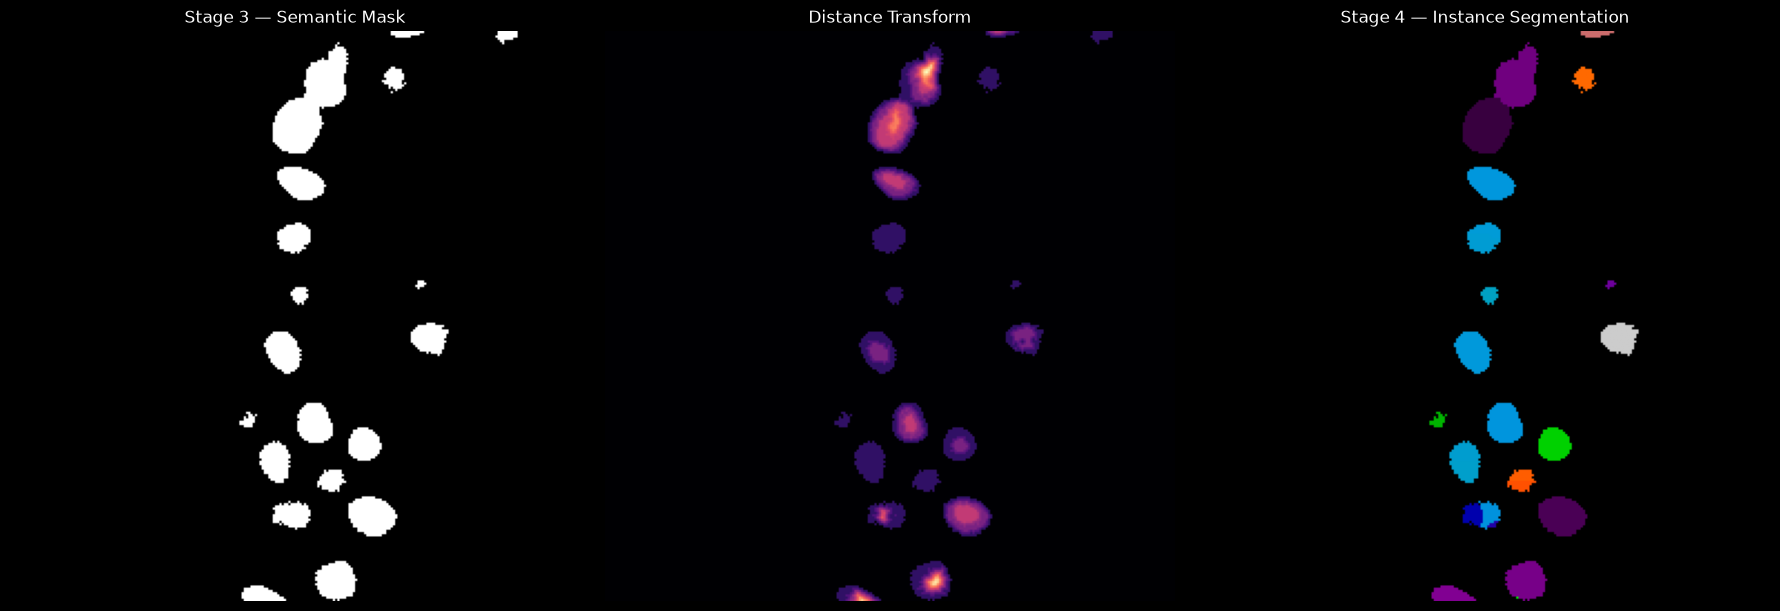

In [53]:
z = 32

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 6)
)

axes[0].imshow(
    binary_mask[z],
    cmap="gray"
)

axes[0].set_title(
    "Stage 3 — Semantic Mask"
)

axes[1].imshow(
    distance[z],
    cmap="magma"
)

axes[1].set_title(
    "Distance Transform"
)

axes[2].imshow(
    instance_labels[z],
    cmap="nipy_spectral"
)

axes[2].set_title(
    "Stage 4 — Instance Segmentation"
)

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [56]:
from src.segmentation.instance import (
    compute_distance_transform,
    detect_cell_centers,
    create_watershed_markers,
    apply_watershed,
)
import pandas as pd

In [59]:
SAMPLE_NAME = "44b6_0113de3b"

STAGE3_DIR = (
        PROJECT_ROOT
        / "data"
        / "sample"
        / "processed"
        / "stage3_segmentation"
        / SAMPLE_NAME
)

binary_mask = np.load(
    STAGE3_DIR / "binary_mask.npy"
)

labeled = np.load(
    STAGE3_DIR / "labeled.npy"
)

objects_df = pd.read_csv(
    STAGE3_DIR / "objects.csv"
)

print("Binary mask shape:", binary_mask.shape)
print("Labeled shape:", labeled.shape)
print("Stage 3 objects:", len(objects_df))

Binary mask shape: (64, 256, 256)
Labeled shape: (64, 256, 256)
Stage 3 objects: 184


In [60]:
distance = compute_distance_transform(
    binary_mask
)

print(
    "Distance transform shape:",
    distance.shape
)

print(
    "Maximum distance:",
    distance.max()
)

Distance transform shape: (64, 256, 256)
Maximum distance: 5.0990195135927845


In [61]:
coordinates = detect_cell_centers(
    distance,
    min_distance=5,
    threshold_abs=2,
)

print(
    "Number of detected peaks:",
    len(coordinates)
)

Number of detected peaks: 254


In [62]:
markers = create_watershed_markers(
    coordinates,
    binary_mask.shape,
)

print(
    "Number of markers:",
    markers.max()
)

Number of markers: 254


In [63]:
instance_labels = apply_watershed(
    distance,
    markers,
    binary_mask,
)

print(
    "Instance segmentation shape:",
    instance_labels.shape
)

print(
    "Number of instances:",
    instance_labels.max()
)

Instance segmentation shape: (64, 256, 256)
Number of instances: 254


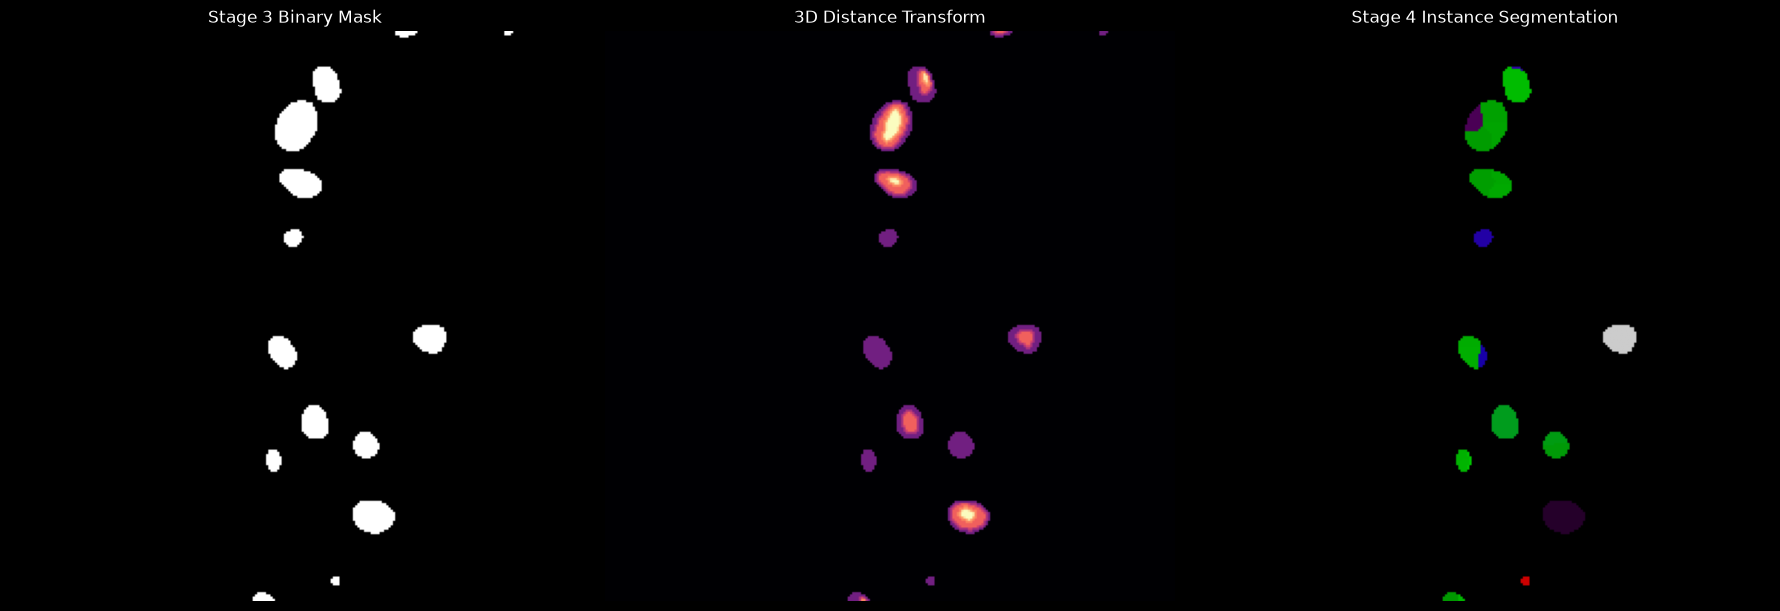

In [64]:
z = 32

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 6),
)

axes[0].imshow(
    binary_mask[z],
    cmap="gray",
)

axes[0].set_title(
    "Stage 3 Binary Mask"
)

axes[1].imshow(
    distance[z],
    cmap="magma",
)

axes[1].set_title(
    "3D Distance Transform"
)

axes[2].imshow(
    instance_labels[z],
    cmap="nipy_spectral",
)

axes[2].set_title(
    "Stage 4 Instance Segmentation"
)

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

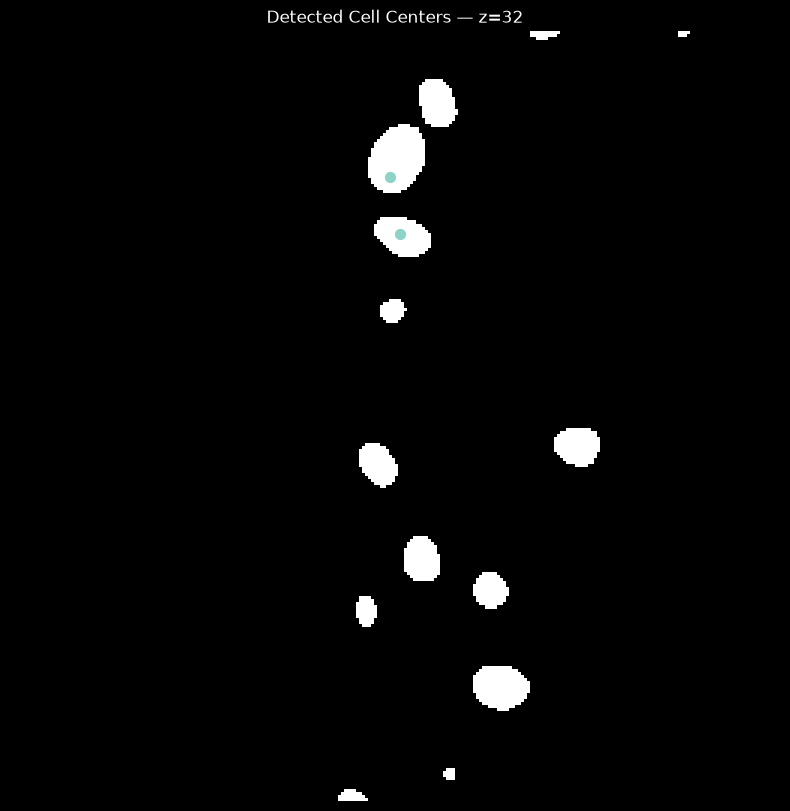

In [65]:
z = 32

plt.figure(figsize=(10, 10))

plt.imshow(
    binary_mask[z],
    cmap="gray"
)

points_at_z = coordinates[
    coordinates[:, 0] == z
    ]

plt.scatter(
    points_at_z[:, 2],
    points_at_z[:, 1],
    s=50,
)

plt.title(
    f"Detected Cell Centers — z={z}"
)

plt.axis("off")

plt.show()

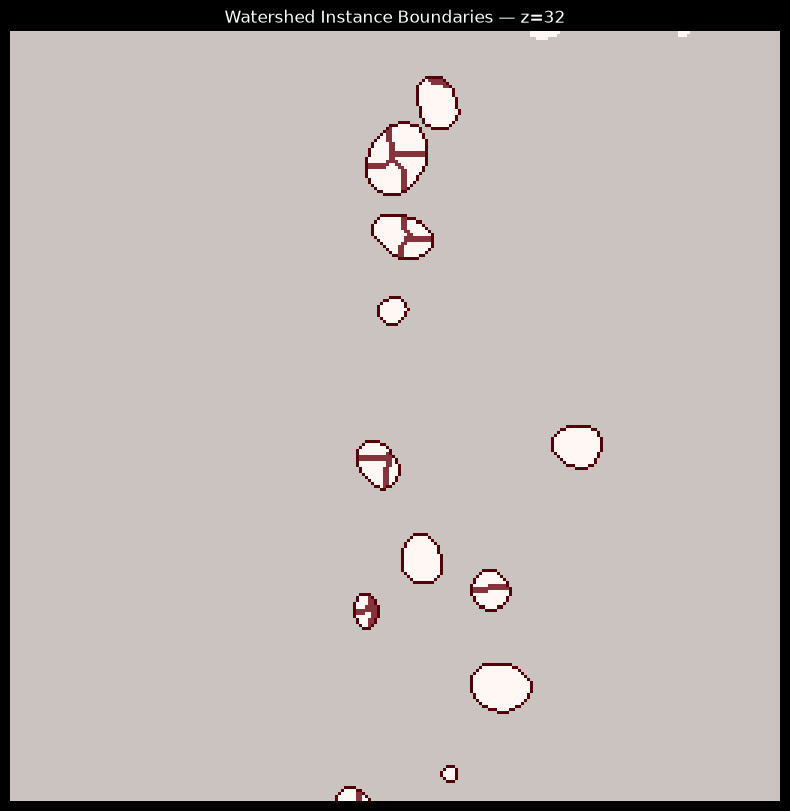

In [66]:
from skimage.segmentation import find_boundaries

z = 32

boundaries = find_boundaries(
    instance_labels[z],
    mode="outer"
)

plt.figure(figsize=(10, 10))

plt.imshow(
    binary_mask[z],
    cmap="gray"
)

plt.imshow(
    boundaries,
    cmap="Reds",
    alpha=0.8
)

plt.title(
    f"Watershed Instance Boundaries — z={z}"
)

plt.axis("off")

plt.show()

Marker Sensitivity Experiment

In [67]:
import numpy as np
import matplotlib.pyplot as plt

from scipy import ndimage
from skimage.feature import peak_local_max
from skimage.segmentation import watershed

In [68]:
distance = ndimage.distance_transform_edt(
    binary_mask
)

print("Distance shape:", distance.shape)
print("Maximum distance:", distance.max())

Distance shape: (64, 256, 256)
Maximum distance: 5.0990195135927845


In [69]:
min_distances = [3, 5, 8, 10, 15]

results = []

In [70]:
for min_distance in min_distances:

    # Detect local maxima
    coordinates = peak_local_max(
        distance,
        min_distance=min_distance,
        threshold_abs=2,
        exclude_border=False
    )

    # Create markers
    markers = np.zeros(
        binary_mask.shape,
        dtype=np.int32
    )

    for marker_id, coord in enumerate(
            coordinates,
            start=1
    ):
        z, y, x = coord

        markers[
            z,
            y,
            x
        ] = marker_id

    # Run watershed
    instance_labels = watershed(
        -distance,
        markers,
        mask=binary_mask
    )

    number_of_markers = len(coordinates)

    number_of_instances = (
        instance_labels.max()
    )

    results.append({
        "min_distance": min_distance,
        "markers": number_of_markers,
        "instances": number_of_instances,
        "coordinates": coordinates,
        "markers_volume": markers,
        "labels": instance_labels
    })

    print(
        f"min_distance={min_distance:2d} | "
        f"markers={number_of_markers:3d} | "
        f"instances={number_of_instances:3d}"
    )

min_distance= 3 | markers=505 | instances=505
min_distance= 5 | markers=254 | instances=254
min_distance= 8 | markers=159 | instances=159
min_distance=10 | markers=134 | instances=134
min_distance=15 | markers= 88 | instances= 88


In [71]:
distances = [
    result["min_distance"]
    for result in results
]

marker_counts = [
    result["markers"]
    for result in results
]

instance_counts = [
    result["instances"]
    for result in results
]

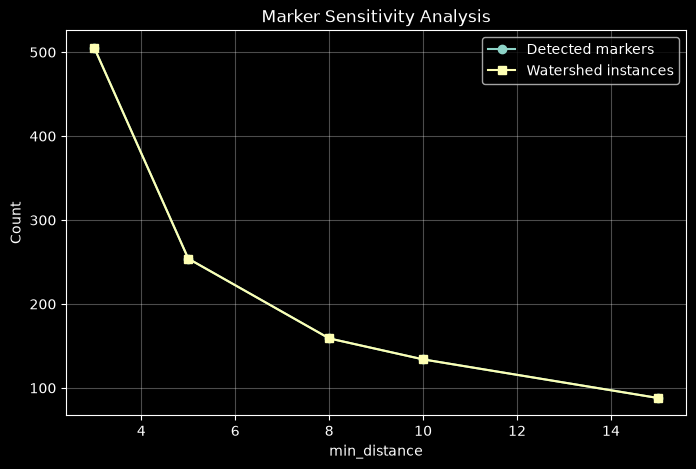

In [72]:
plt.figure(figsize=(8, 5))

plt.plot(
    distances,
    marker_counts,
    marker="o",
    label="Detected markers"
)

plt.plot(
    distances,
    instance_counts,
    marker="s",
    label="Watershed instances"
)

plt.xlabel(
    "min_distance"
)

plt.ylabel(
    "Count"
)

plt.title(
    "Marker Sensitivity Analysis"
)

plt.legend()

plt.grid(
    True,
    alpha=0.3
)

plt.show()

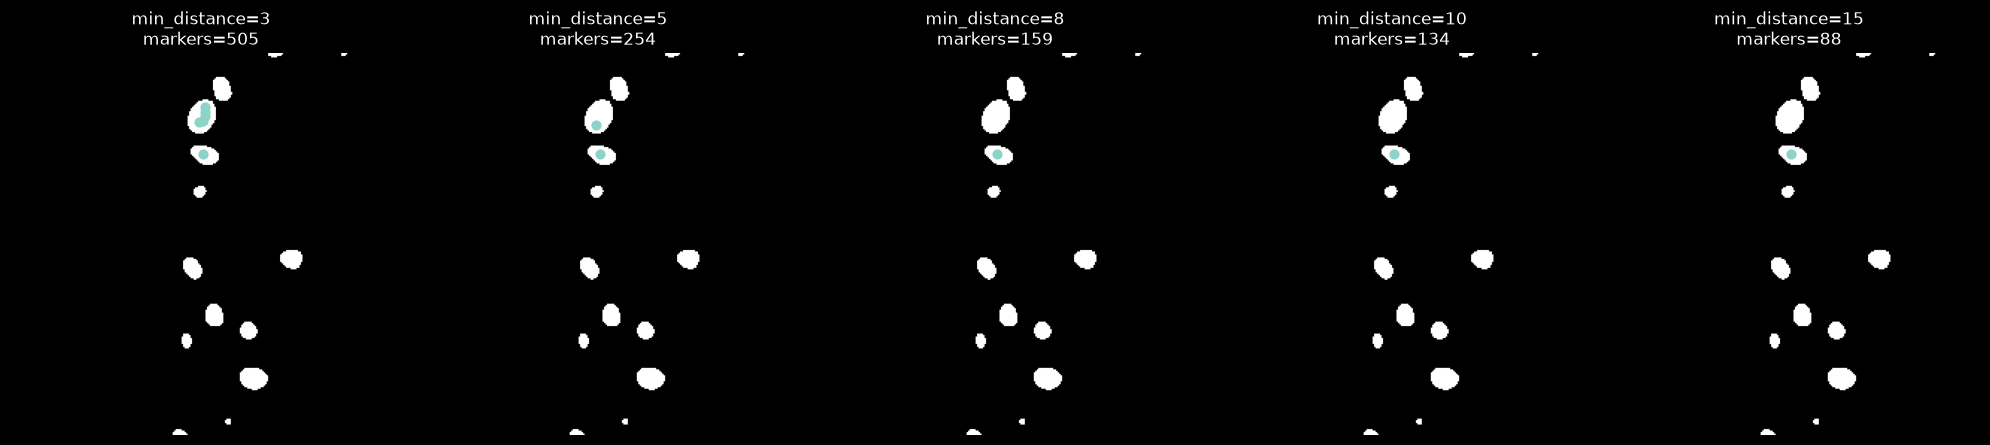

In [73]:
z = 32
fig, axes = plt.subplots(
    1,
    len(results),
    figsize=(20, 5)
)

for ax, result in zip(
        axes,
        results
):

    coordinates = result["coordinates"]

    points_at_z = coordinates[
        coordinates[:, 0] == z
        ]

    ax.imshow(
        binary_mask[z],
        cmap="gray"
    )

    if len(points_at_z) > 0:

        ax.scatter(
            points_at_z[:, 2],
            points_at_z[:, 1],
            s=40
        )

    ax.set_title(
        f"min_distance={result['min_distance']}\n"
        f"markers={result['markers']}"
    )

    ax.axis("off")

plt.tight_layout()
plt.show()